In [33]:
import os
import sys
from datetime import datetime

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [34]:
model_u_mlp, model_k_mlp = build_models(
    device,
    hidden_layers=3,
    hidden_units=25,
    activation=nn.Tanh(),
)

In [35]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [36]:
 
print(f"model_u parameters: {count_parameters(model_u_mlp):,}")
print(f"model_k parameters: {count_parameters(model_k_mlp):,}")

model_u parameters: 2,051
model_k parameters: 2,051


In [37]:
from torchinfo import summary

In [38]:
print("--- Model U Summary ---")
summary(model_u_mlp, input_size=(1, 2))

--- Model U Summary ---


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 1]                    --
├─Linear: 1-1                            [1, 25]                   75
├─ModuleList: 1-6                        --                        (recursive)
│    └─Linear: 2-1                       [1, 25]                   650
├─Tanh: 1-3                              [1, 25]                   --
├─ModuleList: 1-6                        --                        (recursive)
│    └─Linear: 2-2                       [1, 25]                   650
├─Tanh: 1-5                              [1, 25]                   --
├─ModuleList: 1-6                        --                        (recursive)
│    └─Linear: 2-3                       [1, 25]                   650
├─Tanh: 1-7                              [1, 25]                   --
├─Linear: 1-8                            [1, 1]                    26
Total params: 2,051
Trainable params: 2,051
Non-trainab

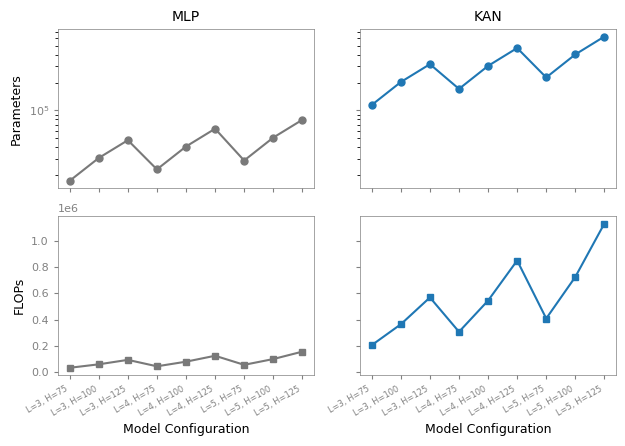

In [48]:
import torch
import matplotlib.pyplot as plt
from calflops import calculate_flops

# -------------------------
# Setup & Configurations
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MLP_WIDTHS = [75, 100, 125]
DEPTHS = [3, 4, 5]

config_labels = []

mlp_params_list, mlp_flops_list = [], []
kan_params_list, kan_flops_list = [], []

batch_size = 1
input_shape = (batch_size, 2)  # Matches input_size=2

# -------------------------
# Evaluation Loop (Silent)
# -------------------------
for depth in DEPTHS:
    for width in MLP_WIDTHS:
        config_label = f"L={depth}, H={width}"
        config_labels.append(config_label)
        
        # 1. Build and evaluate MLP
        model_u_mlp, _ = build_models(
            device,
            hidden_layers=depth,
            hidden_units=width
        )
        flops_mlp, _, params_mlp = calculate_flops(
            model=model_u_mlp, 
            input_shape=input_shape,
            print_results=False,
            print_detailed=False,
            output_as_string=False
        )
        mlp_params_list.append(params_mlp)
        mlp_flops_list.append(flops_mlp)
        
        # 2. Build and evaluate KAN
        # (Adjust arguments if your build_models_KAN signature differs)
        try:
            model_u_kan, _ = build_models_KAN(
                device,
                hidden_layers=depth,
                hidden_units=width,
                grid_size=5,
                spline_order=3,
            )
        except TypeError:
            # Fallback if hidden_layers isn't accepted by build_models_KAN
            model_u_kan, _ = build_models_KAN(
                device,
                hidden_units=width,
                grid_size=5,
                spline_order=3,
            )
            
        flops_kan, _, params_kan = calculate_flops(
            model=model_u_kan, 
            input_shape=input_shape,
            print_results=False,
            print_detailed=False,
            output_as_string=False
        )
        kan_params_list.append(params_kan)
        kan_flops_list.append(flops_kan)

# -------------------------
# Plotting (2x2 Grid: Columns = MLP vs KAN, Rows = Params vs FLOPs)
# -------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.3, 4.5),
    sharex=True,
    sharey='row'  # Shares y-axis scale across columns for direct comparison
)

axis_color = "gray"

# -------------------------
# Row 0: Parameters
# -------------------------
# MLP (Col 0)
axes[0, 0].plot(config_labels, mlp_params_list, marker='o', color='#797979', linewidth=1.5, markersize=5)
axes[0, 0].set_ylabel("Parameters", fontsize=9)
axes[0, 0].set_title("MLP", fontsize=10, color='black')
axes[0, 0].set_yscale('log')  # Log scale for better visibility of parameter differences
 
# KAN (Col 1)
axes[0, 1].plot(config_labels, kan_params_list, marker='o', color='#1f77b4', linewidth=1.5, markersize=5)
axes[0, 1].set_title("KAN", fontsize=10, color='black')
 
# -------------------------
# Row 1: FLOPs
# -------------------------
# MLP (Col 0)
axes[1, 0].plot(config_labels, mlp_flops_list, marker='s', color="#797979", linewidth=1.5, markersize=5)
axes[1, 0].set_ylabel("FLOPs", fontsize=9)
axes[1, 0].set_xlabel("Model Configuration", fontsize=9)

# KAN (Col 1)
axes[1, 1].plot(config_labels, kan_flops_list, marker='s', color='#1f77b4', linewidth=1.5, markersize=5)
axes[1, 1].set_xlabel("Model Configuration", fontsize=9)

# -------------------------
# Styling and Layout Formatting
# -------------------------
for row in axes:
    for ax in row:
        ax.tick_params(axis="both", labelsize=8, colors=axis_color)
        for spine in ax.spines.values():
            spine.set_color(axis_color)
            spine.set_linewidth(0.5)

# Rotate x-tick labels for both bottom subplots
for ax in axes[1, :]:
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right', fontsize=6)

plt.tight_layout()

# Save and Display
plt.savefig("figures/mlp_vs_kan_scaling.svg", bbox_inches="tight", dpi=300)
plt.show()

In [68]:
# -------------------------
# Setup & Configurations
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_shape = (1, 2)

kan_depths = [1, 2, 3]
kan_widths = [25, 30, 35]
kan_grids = [5]
spline_order = 3

mlp_sweep_widths = range(25, 150, 1)

# Separate label lists for each specific plot
kan_labels = []
mlp_param_labels = []
mlp_flop_labels = []

kan_params_list, kan_flops_list = [], []
param_matched_mlp_params, flop_matched_mlp_flops = [], []

# ---------------------------------------------------------
# Execution & Dynamic Budget Matching Loop
# ---------------------------------------------------------
print(f"{'KAN Config':<18} | {'KAN Params':<10} | {'Param-Matched MLP':<18} | {'KAN FLOPs':<10} | {'FLOP-Matched MLP':<18}")
print("-" * 80)

for depth in kan_depths:
    for units in kan_widths:
        for grid in kan_grids:
            
            try:
                model_kan, _ = build_models_KAN(
                    device, hidden_layers=depth, hidden_units=units, 
                    grid_size=grid, spline_order=spline_order
                )
            except TypeError:
                model_kan, _ = build_models_KAN(
                    device, hidden_units=units, grid_size=grid, spline_order=spline_order
                )
            
            kan_flops, _, kan_params = calculate_flops(
                model_kan, input_shape=input_shape, 
                print_results=False, print_detailed=False, output_as_string=False
            )
            
            best_p_width, min_p_diff, best_p_val = None, float('inf'), 0
            best_f_width, min_f_diff, best_f_val = None, float('inf'), 0
            
            for m_width in mlp_sweep_widths:
                model_mlp, _ = build_models(device, hidden_layers=depth, hidden_units=m_width)
                mlp_flops, _, mlp_params = calculate_flops(
                    model_mlp, input_shape=input_shape, 
                    print_results=False, print_detailed=False, output_as_string=False
                )
                
                if abs(mlp_params - kan_params) < min_p_diff:
                    min_p_diff = abs(mlp_params - kan_params)
                    best_p_width = m_width
                    best_p_val = mlp_params
                    
                if abs(mlp_flops - kan_flops) < min_f_diff:
                    min_f_diff = abs(mlp_flops - kan_flops)
                    best_f_width = m_width
                    best_f_val = mlp_flops

            # Build distinct labels
            kan_labels.append(f"L={depth}\nK:{units}")
            mlp_param_labels.append(f"L={depth}\nM:{best_p_width}")
            mlp_flop_labels.append(f"L={depth}\nM:{best_f_width}")
            
            kan_params_list.append(kan_params)
            kan_flops_list.append(kan_flops)
            param_matched_mlp_params.append(best_p_val)
            flop_matched_mlp_flops.append(best_f_val)

            print(f"L={depth},H={units},G={grid}   | {kan_params:<10,} | L={depth},H={best_p_width} [{best_p_val}] | {kan_flops:<10,} | L={depth},H={best_f_width} [{best_f_val}]")

KAN Config         | KAN Params | Param-Matched MLP  | KAN FLOPs  | FLOP-Matched MLP  
--------------------------------------------------------------------------------
L=1,H=25,G=5   | 750        | L=1,H=25 [751] | 1,377      | L=1,H=25 [1400]
L=1,H=30,G=5   | 900        | L=1,H=28 [925] | 1,652      | L=1,H=27 [1620]
L=1,H=35,G=5   | 1,050      | L=1,H=30 [1051] | 1,927      | L=1,H=30 [1980]
L=2,H=25,G=5   | 7,000      | L=2,H=58 [7077] | 12,652     | L=2,H=55 [12430]
L=2,H=30,G=5   | 9,900      | L=2,H=69 [9937] | 17,882     | L=2,H=66 [17820]
L=2,H=35,G=5   | 13,300     | L=2,H=80 [13281] | 24,012     | L=2,H=77 [24178]
L=3,H=25,G=5   | 13,250     | L=3,H=65 [13131] | 23,927     | L=3,H=63 [24192]
L=3,H=30,G=5   | 18,900     | L=3,H=78 [18799] | 34,112     | L=3,H=75 [34200]
L=3,H=35,G=5   | 25,550     | L=3,H=91 [25481] | 46,097     | L=3,H=87 [45936]


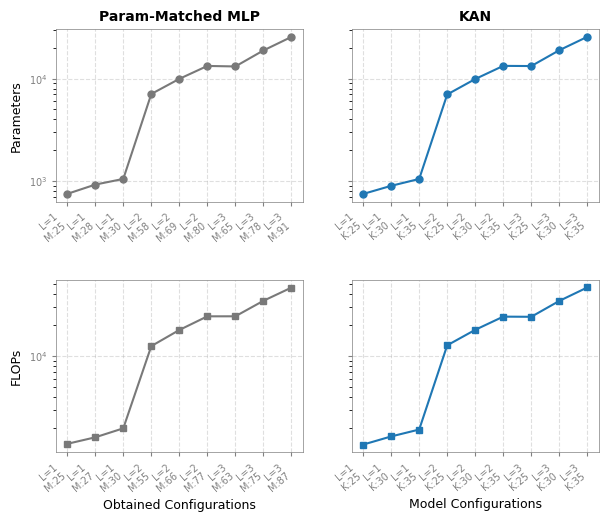

In [ ]:
# ---------------------------------------------------------
# Plotting (2x2 Grid with Decoupled X-Axes)
# ---------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.0, 5.5),
    sharex=False,  # Set to False to allow distinct X-labels per plot
    sharey='row'
)

axis_color = "gray"
x_indices = range(len(kan_labels))

# Row 0: Parameters Comparison
axes[0, 0].plot(x_indices, param_matched_mlp_params, marker='o', color='#797979', linewidth=1.5, markersize=5)
axes[0, 0].set_ylabel("Parameters", fontsize=9)
axes[0, 0].set_title("MLP", fontsize=10, fontweight='bold', color='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xticks(x_indices)
axes[0, 0].set_xticklabels(mlp_param_labels)

axes[0, 1].plot(x_indices, kan_params_list, marker='o', color='#1f77b4', linewidth=1.5, markersize=5)
axes[0, 1].set_title("KAN", fontsize=10, fontweight='bold', color='black')
axes[0, 1].set_xticks(x_indices)
axes[0, 1].set_xticklabels(kan_labels)

# Row 1: FLOPs Comparison
axes[1, 0].plot(x_indices, flop_matched_mlp_flops, marker='s', color="#797979", linewidth=1.5, markersize=5)
axes[1, 0].set_ylabel("FLOPs", fontsize=9)
axes[1, 0].set_xlabel("Obtained Configurations", fontsize=9)
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticks(x_indices)
axes[1, 0].set_xticklabels(mlp_flop_labels)

axes[1, 1].plot(x_indices, kan_flops_list, marker='s', color='#1f77b4', linewidth=1.5, markersize=5)
axes[1, 1].set_xlabel("Model Configurations", fontsize=9)
axes[1, 1].set_xticks(x_indices)
axes[1, 1].set_xticklabels(kan_labels)

# Styling and Formatting
for row in axes:
    for ax in row:
        ax.tick_params(axis="both", labelsize=7, colors=axis_color)
        ax.grid(True, linestyle='--', alpha=0.4)
        for spine in ax.spines.values():
            spine.set_color(axis_color)
            spine.set_linewidth(0.5)
        
        # Apply rotation to all subplots now that sharex=False
        plt.sca(ax)
        plt.xticks(rotation=40, ha='right')

plt.subplots_adjust(hspace=0.45) # Increase vertical space for the visible top x-ticks
plt.savefig("figures/budget_matched_scaling.svg", bbox_inches="tight", dpi=300)
plt.show()